# Import All Needed Libraries

In [83]:
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib

In [84]:
# Load data
df = pd.read_csv('data/smokes.csv')

# Drop None value
df.dropna(inplace=True)

print(df.head())

  First Name Last Name  Vape Name Vape Type  Air Inhaled  \
1     Marcus  Thompson       smok      tank         4.12   
2       Emma      Chen     voopoo       mod         3.89   
3      James  Robinson  geek vape      tank         2.34   
4     Olivia   Jackson     aspire       pod         1.67   
5      David     White  vaporesso       mod         5.23   

   Nicotine Concentration  Target  
1                       6   24.72  
2                      12   46.68  
3                      18   42.12  
4                      20   33.40  
5                       8   41.84  


In [85]:
# Prepare features and target
X = df[['Air Inhaled', 'Nicotine Concentration']]
y = df['Target']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()

print(f"Categorical columns: {cat_cols if cat_cols else 'None'}")
print(f"Numerical columns: {num_cols}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ]
)

# Create full pipeline with XGBoost Regressor
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    ))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

# Fit model
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Saves the model
joblib.dump(model, 'nicotine_calculator/model.pkl')
print("Model saved as 'nicotine_calculator_model.pkl'")


Categorical columns: None
Numerical columns: ['Air Inhaled', 'Nicotine Concentration']
Model saved as 'nicotine_calculator_model.pkl'


=== REGRESSION METRICS ===
MAE: 9.7258
RMSE: 17.4013
R² Score: 0.7336
MAPE: 0.2153


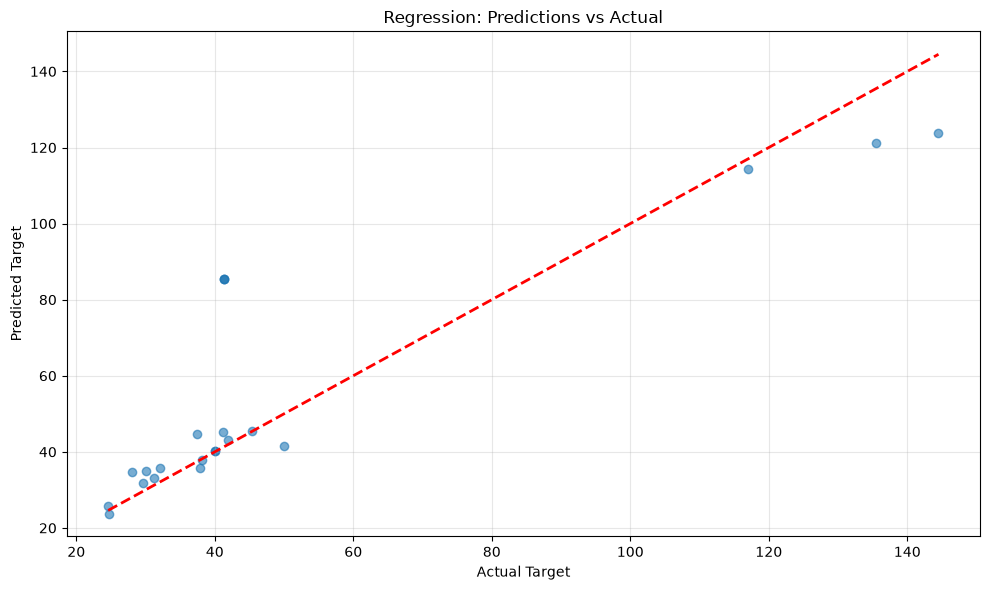

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

print("=== REGRESSION METRICS ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_test):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test):.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.title('Regression: Predictions vs Actual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
import numpy as np

print(f"\n{'Threshold':<12} | {'Predictions Above':<18} | {'Avg Error':<12} | {'Max Error':<12}")
print("-" * 60)

for threshold in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    # Get predictions above threshold
    mask = y_pred_test >= threshold
    count_above = mask.sum()
    
    # Calculate error metrics for predictions above threshold
    if count_above > 0:
        y_actual_filtered = y_test[mask]
        y_pred_filtered = y_pred_test[mask]
        mae = np.mean(np.abs(y_actual_filtered - y_pred_filtered))
        max_error = np.max(np.abs(y_actual_filtered - y_pred_filtered))
    else:
        mae = 0
        max_error = 0
    
    print(f"{threshold:.2f}       | {count_above:4d} ({count_above/len(y_test)*100:5.1f}%) | {mae:10.4f} | {max_error:10.4f}")


Threshold    | Predictions Above  | Avg Error    | Max Error   
------------------------------------------------------------
0.50       |   22 (100.0%) |     9.7258 |    43.9243
0.55       |   22 (100.0%) |     9.7258 |    43.9243
0.60       |   22 (100.0%) |     9.7258 |    43.9243
0.65       |   22 (100.0%) |     9.7258 |    43.9243
0.70       |   22 (100.0%) |     9.7258 |    43.9243
0.75       |   22 (100.0%) |     9.7258 |    43.9243
0.80       |   22 (100.0%) |     9.7258 |    43.9243


In [88]:
# For regression: analyze predictions and their accuracy
threshold = 70  # Actual Target value threshold, not prediction probability

print(f"\n=== Analysis (Target threshold={threshold}) ===")

# Cases where actual Target >= threshold
high_target_mask = y_test >= threshold
num_high_target = high_target_mask.sum()

# Predictions for those cases
preds_for_high = y_pred_test[high_target_mask]
actuals_for_high = y_test[high_target_mask]

# Error metrics
mae = np.mean(np.abs(preds_for_high - actuals_for_high))
rmse = np.sqrt(np.mean((preds_for_high - actuals_for_high) ** 2))
r2 = r2_score(actuals_for_high, preds_for_high)

print(f"Cases with Target >= {threshold}: {num_high_target}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

print(f"\nActual Targets (high risk):")
print(f"  Sum: {actuals_for_high.sum():.2f}")
print(f"  Mean: {actuals_for_high.mean():.4f}")
print(f"  Median: {actuals_for_high.median():.4f}")

print(f"\nPredicted Targets (high risk):")
print(f"  Sum: {preds_for_high.sum():.2f}")
print(f"  Mean: {preds_for_high.mean():.4f}")
print(f"  Median: {np.median(preds_for_high):.4f}")


=== Analysis (Target threshold=70) ===
Cases with Target >= 70: 3
MAE: 12.4934
RMSE: 14.5488
R² Score: -0.6151

Actual Targets (high risk):
  Sum: 397.00
  Mean: 132.3333
  Median: 135.5000

Predicted Targets (high risk):
  Sum: 359.52
  Mean: 119.8399
  Median: 121.1936
